# Market Basket Analysis — Association Rules
### SafeX Solutions Data Science Internship | Week 3

## 1. Import Libraries & Setup

In [42]:
import warnings
warnings.filterwarnings("ignore")

In [10]:
from google.colab import files

uploaded = files.upload()

!pip install mlxtend openpyxl -q

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [12]:
df = pd.read_excel('Online Retail.xlsx')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Description'] = (
    df['Description']
    .astype('string')
    .str.strip()
    .str.upper()
)



## 3. Initial Data Inspection

In [13]:
print("Original rows:", len(df))

df.head()

Original rows: 541909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  string        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3), string(1)
memory usage: 33.1+ MB


In [15]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## 4. Data Cleaning & Preprocessing

In [16]:
df_clean = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (df['Description'].notna()) &
    (~df['InvoiceNo'].astype(str).str.startswith('C'))
].copy()

print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Rows after cleaning: 530104
Rows removed: 11805


### 4.1 Duplicate and Missing Value Handling

In [17]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 5226


In [18]:
df_clean = df_clean.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df_clean))
print("Duplicates remaining:", df_clean.duplicated().sum())

Rows after removing duplicates: 524878
Duplicates remaining: 0


In [19]:
print("Missing values:")
print(df_clean.isnull().sum())


Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64


## 5. Dataset Summary

In [20]:
print("Unique transactions:", df_clean['InvoiceNo'].nunique())
print("Unique products:", df_clean['StockCode'].nunique())
print("Unique product descriptions:", df_clean['Description'].nunique())

Unique transactions: 19960
Unique products: 3922
Unique product descriptions: 4015


In [21]:
df_clean['Country'].value_counts().head(10)

,count
Country,
United Kingdom,479985
Germany,9025
France,8392
EIRE,7879
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1958
Portugal,1492


In [22]:
transaction_summary = df_clean.groupby('InvoiceNo').agg(
    unique_products=('StockCode', 'nunique'),
    total_items=('Quantity', 'sum')
)


In [23]:
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']


In [24]:
print("Total Revenue: £{:,.2f}".format(df_clean['Sales'].sum()))
print("Total Transactions:", df_clean['InvoiceNo'].nunique())
print("Unique Products:", df_clean['StockCode'].nunique())
print("Countries:", df_clean['Country'].nunique())

Total Revenue: £10,642,110.80
Total Transactions: 19960
Unique Products: 3922
Countries: 38


## 6. Exploratory Data Analysis

### 6.1 Monthly Sales Trend

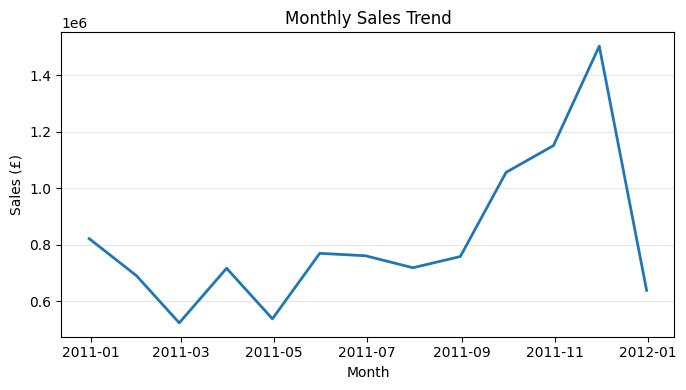

In [25]:
monthly_sales = df_clean.resample(
    'ME',
    on='InvoiceDate'
)['Sales'].sum()

plt.figure(figsize=(7, 4))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales (£)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Top 10 Most Purchased Products

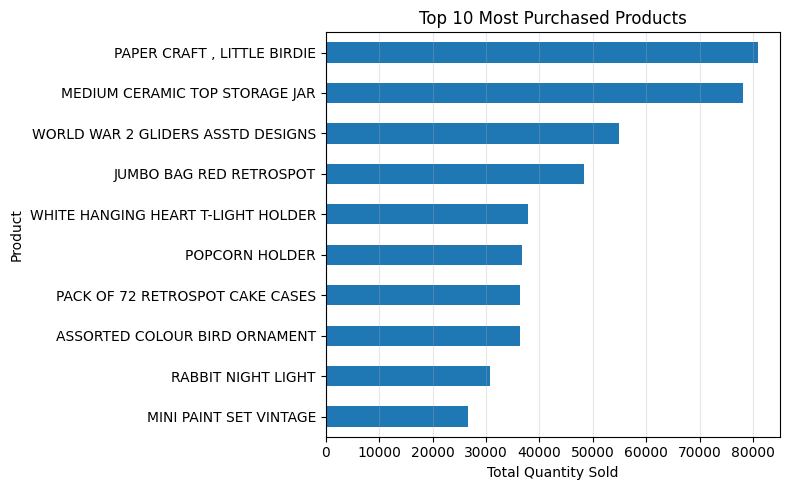

In [26]:
top_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Most Purchased Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Top 10 Products by Revenue

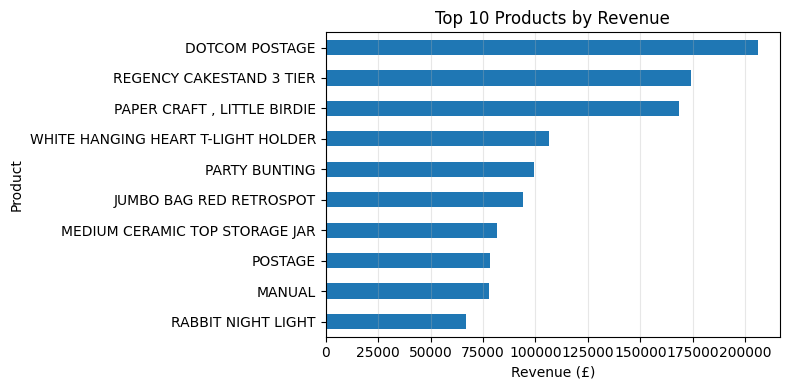

In [27]:
top_revenue_products = (
    df_clean.groupby('Description')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))

top_revenue_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Distribution of Products per Transaction

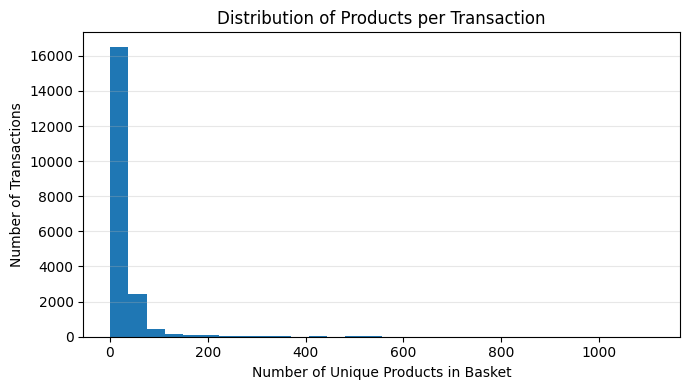

In [28]:
plt.figure(figsize=(7, 4))

plt.hist(
    transaction_summary['unique_products'],
    bins=30
)

plt.title('Distribution of Products per Transaction')
plt.xlabel('Number of Unique Products in Basket')
plt.ylabel('Number of Transactions')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 Top 10 Countries by Transaction Records

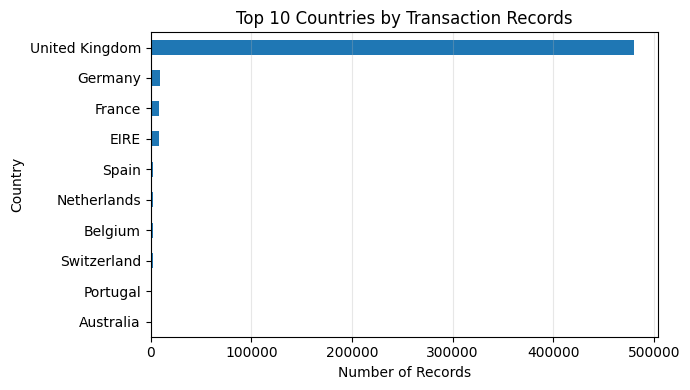

In [29]:
top_countries = df_clean['Country'].value_counts().head(10)

plt.figure(figsize=(7, 4))

top_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Transaction Records')
plt.xlabel('Number of Records')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
print(
    "Average unique products per transaction:",
    round(transaction_summary['unique_products'].mean(), 2)
)

print(
    "Median unique products per transaction:",
    transaction_summary['unique_products'].median()
)

Average unique products per transaction: 26.03
Median unique products per transaction: 15.0


## 7. Remove Non-Product and Service Items

In [31]:
# Remove non-merchandise/service items
non_product_items = [
    'POSTAGE',
    'DOTCOM POSTAGE',
    'MANUAL',
    'BANK CHARGES',
    'SAMPLES',
    'NEXT DAY CARRIAGE'
]

rows_before = len(df_clean)

df_clean = df_clean[
    ~df_clean['Description'].isin(non_product_items)
].copy()

print("Rows after removing non-product items:", len(df_clean))
print("Rows removed:", rows_before - len(df_clean))

Rows after removing non-product items: 522636
Rows removed: 2242


## 8. Chronological Train–Validation Split

In [32]:
invoice_dates = (
    df_clean.groupby('InvoiceNo')['InvoiceDate']
    .min()
    .sort_values()
)

split_point = int(len(invoice_dates) * 0.8)

train_invoices = invoice_dates.iloc[:split_point].index
validation_invoices = invoice_dates.iloc[split_point:].index

train_df = df_clean[df_clean['InvoiceNo'].isin(train_invoices)]
validation_df = df_clean[df_clean['InvoiceNo'].isin(validation_invoices)]

print("Training transactions:", train_df['InvoiceNo'].nunique())
print("Validation transactions:", validation_df['InvoiceNo'].nunique())

Training transactions: 15823
Validation transactions: 3956


## 9. Create Transaction Basket Matrices

In [33]:
train_basket = train_df.pivot_table(
    index='InvoiceNo',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

train_basket = (train_basket > 0).astype(bool)

print("Training basket shape:", train_basket.shape)

validation_basket = validation_df.pivot_table(
    index='InvoiceNo',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

validation_basket = (validation_basket > 0).astype(bool)

validation_basket = validation_basket.reindex(
    columns=train_basket.columns,
    fill_value=False
)

print("Validation basket shape:", validation_basket.shape)

Training basket shape: (15823, 3841)
Validation basket shape: (3956, 3841)


## 10. Frequent Itemset Mining with Apriori

In [43]:

from mlxtend.frequent_patterns import apriori

train_itemsets = apriori(
    train_basket,
    min_support=0.03,
    use_colnames=True
)

print("Frequent itemsets found:", len(train_itemsets))

Frequent itemsets found: 139


## 11. Generate Association Rules

In [44]:
from mlxtend.frequent_patterns import association_rules

train_rules = association_rules(
    train_itemsets,
    metric='confidence',
    min_threshold=0.3
)

print("Association rules found:", len(train_rules))

Association rules found: 24


## 12. Out-of-Sample Validation

In [45]:
top_train_rules = train_rules.sort_values(
    'lift', ascending=False
).head(30).copy()

validation_results = []

for _, rule in top_train_rules.iterrows():
    antecedent = list(rule['antecedents'])
    consequent = list(rule['consequents'])

    matching = validation_basket[
        validation_basket[antecedent].all(axis=1)
    ]

    if len(matching) > 0:
        validation_confidence = (
            matching[consequent].all(axis=1).mean()
        )
    else:
        validation_confidence = 0

    validation_results.append(validation_confidence)

top_train_rules['validation_confidence'] = validation_results

print("Validation completed.")

Validation completed.


In [46]:
top_train_rules[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'validation_confidence']
]

,antecedents,consequents,support,confidence,lift,validation_confidence
18,(22698),(22697),0.033432,0.833071,15.082014,0.792308
17,(22697),(22698),0.033432,0.605263,15.082014,0.741007
22,(22699),(22698),0.031473,0.541893,13.502959,0.684932
21,(22698),(22699),0.031473,0.784252,13.502959,0.769231
19,(22697),(22699),0.041838,0.757437,13.041270,0.755396
20,(22699),(22697),0.041838,0.720348,13.041270,0.719178
10,(22383),(20727),0.030652,0.443733,6.636281,0.518325
9,(20727),(22383),0.030652,0.458412,6.636281,0.460465
6,(22384),(20725),0.033243,0.560170,6.599833,0.529801
7,(20725),(22384),0.033243,0.391660,6.599833,0.360360


## 13. Business-Friendly Rule Results

In [47]:
product_names = (
    df_clean.drop_duplicates('StockCode')
    .set_index('StockCode')['Description']
    .to_dict()
)

In [48]:
validation_display = top_train_rules.copy()

validation_display['antecedents'] = validation_display['antecedents'].apply(
    lambda x: ', '.join(product_names.get(i, str(i)) for i in x)
)

validation_display['consequents'] = validation_display['consequents'].apply(
    lambda x: ', '.join(product_names.get(i, str(i)) for i in x)
)

validation_display[
    ['antecedents', 'consequents', 'support',
     'confidence', 'lift', 'validation_confidence']
]

,antecedents,consequents,support,confidence,lift,validation_confidence
18,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.033432,0.833071,15.082014,0.792308
17,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.033432,0.605263,15.082014,0.741007
22,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.031473,0.541893,13.502959,0.684932
21,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.031473,0.784252,13.502959,0.769231
19,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.041838,0.757437,13.041270,0.755396
20,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.041838,0.720348,13.041270,0.719178
10,LUNCH BAG SUKI DESIGN,LUNCH BAG BLACK SKULL.,0.030652,0.443733,6.636281,0.518325
9,LUNCH BAG BLACK SKULL.,LUNCH BAG SUKI DESIGN,0.030652,0.458412,6.636281,0.460465
6,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,0.033243,0.560170,6.599833,0.529801
7,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT,0.033243,0.391660,6.599833,0.360360


## 14. Export Recommendations for Streamlit Dashboard

In [49]:
# Export only the 6 columns needed by the Streamlit dashboard
dashboard_rules = validation_display[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift',
        'validation_confidence'
    ]
].copy()

dashboard_rules.to_csv(
    "safex_market_basket_recommendations.csv",
    index=False
)

print("Saved successfully to safex_market_basket_recommendations.csv")

# Trigger browser download
from google.colab import files
files.download("safex_market_basket_recommendations.csv")

Saved successfully to safex_market_basket_recommendations.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>